In [1]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

connected to port: 53998


In [2]:
path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

In [4]:
all_matches = corpus.search(grewpy.Request("pattern{X[upos=ADV]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]"), clustering_parameter=['X.lemma'])

In [5]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [6]:
with open("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/4. occurrences_as_features/patterns_adv_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [7]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [8]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [9]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(123, 185)


In [12]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import AffinityPropagation

In [15]:
af = AffinityPropagation(random_state=0).fit(X)
cluster_centers_indices = af.cluster_centers_indices_
print(f"{cluster_centers_indices=}")
labels = af.labels_
n_clusters_ = len(cluster_centers_indices)
print("Estimated number of clusters: %d" % n_clusters_)

print(
    "Silhouette Coefficient: %0.3f"
    % metrics.silhouette_score(X, labels, metric="sqeuclidean")
)

cluster_centers_indices=array([  1,   2,   4,   5,  10,  13,  15,  17,  18,  19,  25,  30,  32,
        35,  39,  57,  64,  65,  67,  68,  74,  77,  80,  87,  89,  90,
       106, 109, 113, 121])
Estimated number of clusters: 30
Silhouette Coefficient: 0.317


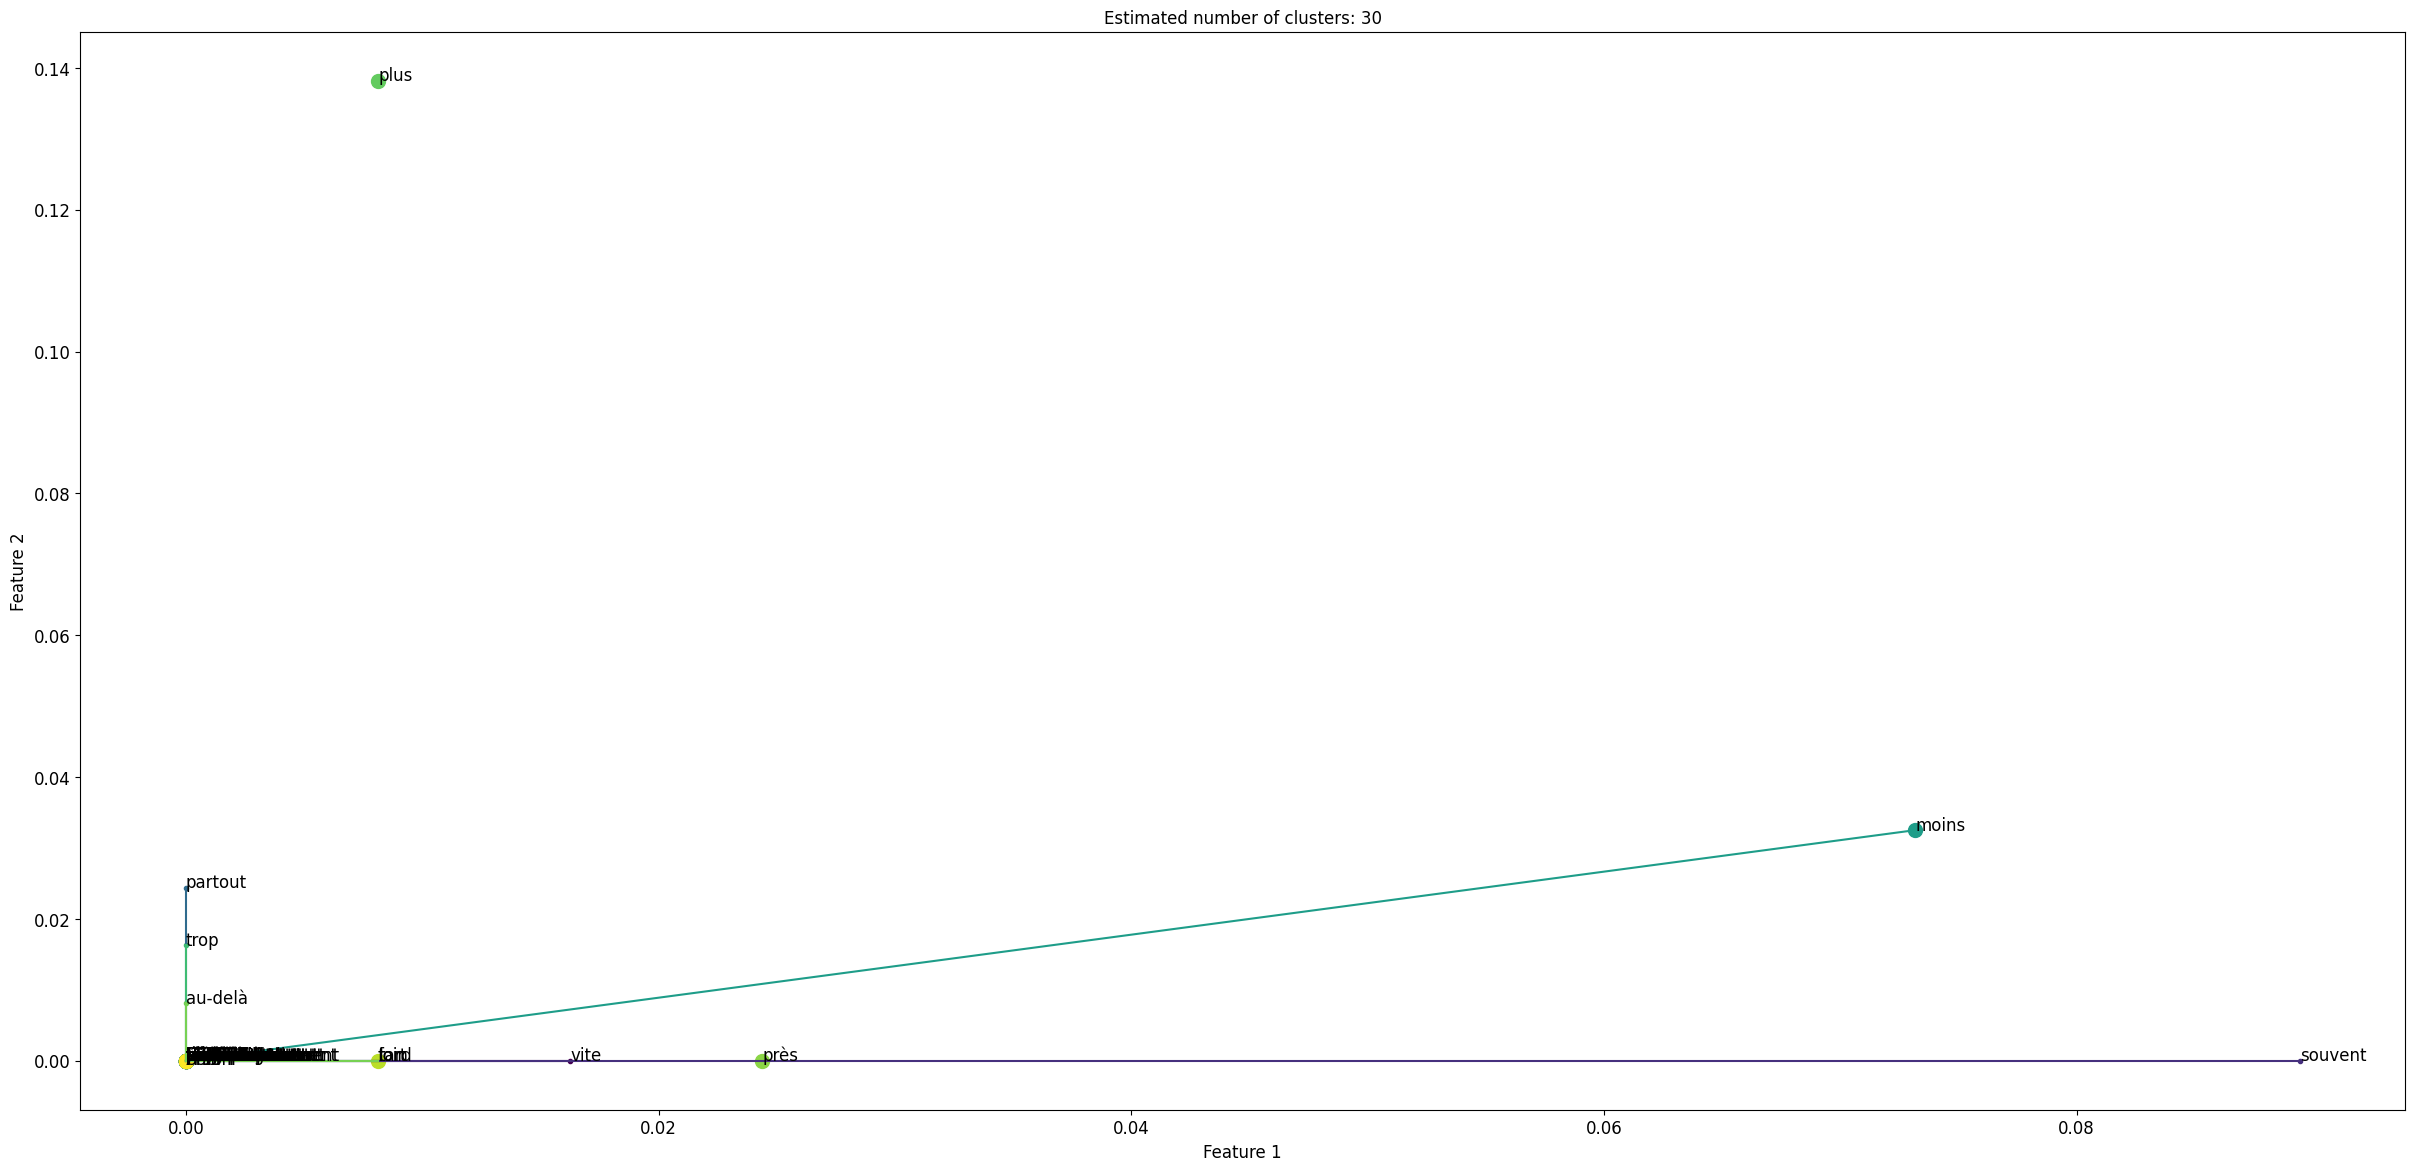

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AffinityPropagation

# Assuming X is your data and unique_adv contains the labels for the data points
affinity_propagation = AffinityPropagation(random_state=0)
labels = affinity_propagation.fit_predict(X)
cluster_centers_indices = affinity_propagation.cluster_centers_indices_
n_clusters_ = len(cluster_centers_indices)

plt.close("all")
plt.figure(figsize=(30, 14))
plt.clf()

colors = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, n_clusters_)))

for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = X[cluster_centers_indices[k]]
    plt.scatter(
        X[class_members, 0], X[class_members, 1], color=col["color"], marker="."
    )
    plt.scatter(
        cluster_center[0], cluster_center[1], s=100, color=col["color"], marker="o"
    )
    for x in X[class_members]:
        plt.plot(
            [cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"]
        )

# Add labels to the plot
for i, txt in enumerate(unique_adv):
    plt.annotate(txt, (X[i, 0], X[i, 1]), fontsize=12)

plt.title("Estimated number of clusters: %d" % n_clusters_, fontsize=12)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()